# Project 6 | Notebook 2: Structural Change Maps

## Overview

This notebook produces choropleth maps documenting the spatial distribution
of structural change across Indian districts from 1990 to 2013. It uses the
district-level panel GeoDataFrame constructed in Notebook 1.

The analysis proceeds in four stages:

1. **Setup and data loading** — reload the processed GeoPackage, confirm
   the panel is intact
2. **Non-farm employment share maps** — four maps (1990, 1998, 2005, 2013)
   on a common scale, showing the geographic spread of structural
   transformation over two decades
3. **Manufacturing share maps** — four maps showing which districts
   industrialised vs. moved directly into services
4. **Change maps** — absolute change in non-farm share over 1990–2013
   and 2005–2013, showing where transformation was fastest

**Input:**
- `data/processed/districts_structural_change.gpkg` — panel GeoDataFrame
  from Notebook 1

**Outputs:**
- `figures/nonfarm_share_4panel.png` — four-panel non-farm share map
- `figures/manuf_share_4panel.png` — four-panel manufacturing share map
- `figures/change_nonfarm_2panel.png` — change maps (full period + recent)

In [1]:
# ─────────────────────────────────────────────────────────────
# Project 6 | Notebook 2: Stage 1 — Setup and data loading
# ─────────────────────────────────────────────────────────────

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

# ── Paths ─────────────────────────────────────────────────────
PROJECT_ROOT = Path('..')
DATA_PROC    = PROJECT_ROOT / 'data' / 'processed'
FIGURES      = PROJECT_ROOT / 'figures'

# ── Plot style ────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Load panel ────────────────────────────────────────────────
panel = gpd.read_file(DATA_PROC / 'districts_structural_change.gpkg')

print(f"Panel shape  : {panel.shape}")
print(f"CRS          : {panel.crs}")
print(f"Columns      : {panel.columns.tolist()}")

Panel shape  : (640, 35)
CRS          : EPSG:4326
Columns      : ['DISTRICT', 'ST_NM', 'ST_CEN_CD', 'censuscode', 'ec90_emp_all', 'ec90_emp_manuf', 'ec90_emp_services', 'ec98_emp_all', 'ec98_emp_manuf', 'ec98_emp_services', 'ec05_emp_all', 'ec05_emp_manuf', 'ec05_emp_services', 'ec13_emp_all', 'ec13_emp_manuf', 'ec13_emp_services', 'pc91_pca_tot_p', 'pc01_pca_tot_p', 'pc11_pca_tot_p', 'nonfarm_share_90', 'manuf_share_90', 'serv_share_90', 'nonfarm_share_98', 'manuf_share_98', 'serv_share_98', 'nonfarm_share_05', 'manuf_share_05', 'serv_share_05', 'nonfarm_share_13', 'manuf_share_13', 'serv_share_13', 'delta_nonfarm_90_13', 'delta_nonfarm_98_13', 'delta_nonfarm_05_13', 'geometry']


### Stage 1 — Output

Panel loaded successfully from GeoPackage:
- 640 districts, 35 columns, geometry intact at EPSG:4326
- All four EC rounds present: `nonfarm_share_90/98/05/13`,
  `manuf_share_90/98/05/13`, `serv_share_90/98/05/13`
- Change indicators present: `delta_nonfarm_90_13`, `delta_nonfarm_98_13`,
  `delta_nonfarm_05_13`

Ready for mapping.

## Stage 2 — Non-Farm Employment Share Maps (1990–2013)

We produce four choropleth maps of non-farm employment share — one per
Economic Census round — arranged as a 2×2 panel. Using a common colour
scale and classification scheme across all four maps is critical: it
allows the reader to compare spatial patterns directly across time without
the maps being distorted by different legend ranges.

We use a **quantile scheme with 5 classes** applied to the pooled
distribution across all four rounds combined. This ensures the colour
thresholds are the same in every panel, making temporal comparison valid.

Districts with missing data (grey) are EC1990 coverage gaps — documented
in Notebook 1.

In [2]:
# ─────────────────────────────────────────────────────────────
# Stage 2 — Compute common scale for non-farm share maps
# ─────────────────────────────────────────────────────────────

import mapclassify

# Pool all four rounds to get a common distribution
nonfarm_cols = ['nonfarm_share_90', 'nonfarm_share_98',
                'nonfarm_share_05', 'nonfarm_share_13']

pooled = pd.concat([panel[c].dropna() for c in nonfarm_cols])

# Compute quintile breaks on the pooled distribution
classifier = mapclassify.Quantiles(pooled, k=5)
breaks     = classifier.bins

print("Common quantile breaks for non-farm share (per 1,000 population):")
print([f"{b:.1f}" for b in breaks])
print(f"\nPooled distribution summary:")
print(f"  min    : {pooled.min():.1f}")
print(f"  median : {pooled.median():.1f}")
print(f"  mean   : {pooled.mean():.1f}")
print(f"  max    : {pooled.max():.1f}")

Common quantile breaks for non-farm share (per 1,000 population):
['30.9', '47.0', '64.9', '91.6', '682.7']

Pooled distribution summary:
  min    : 0.1
  median : 55.1
  mean   : 68.9
  max    : 682.7


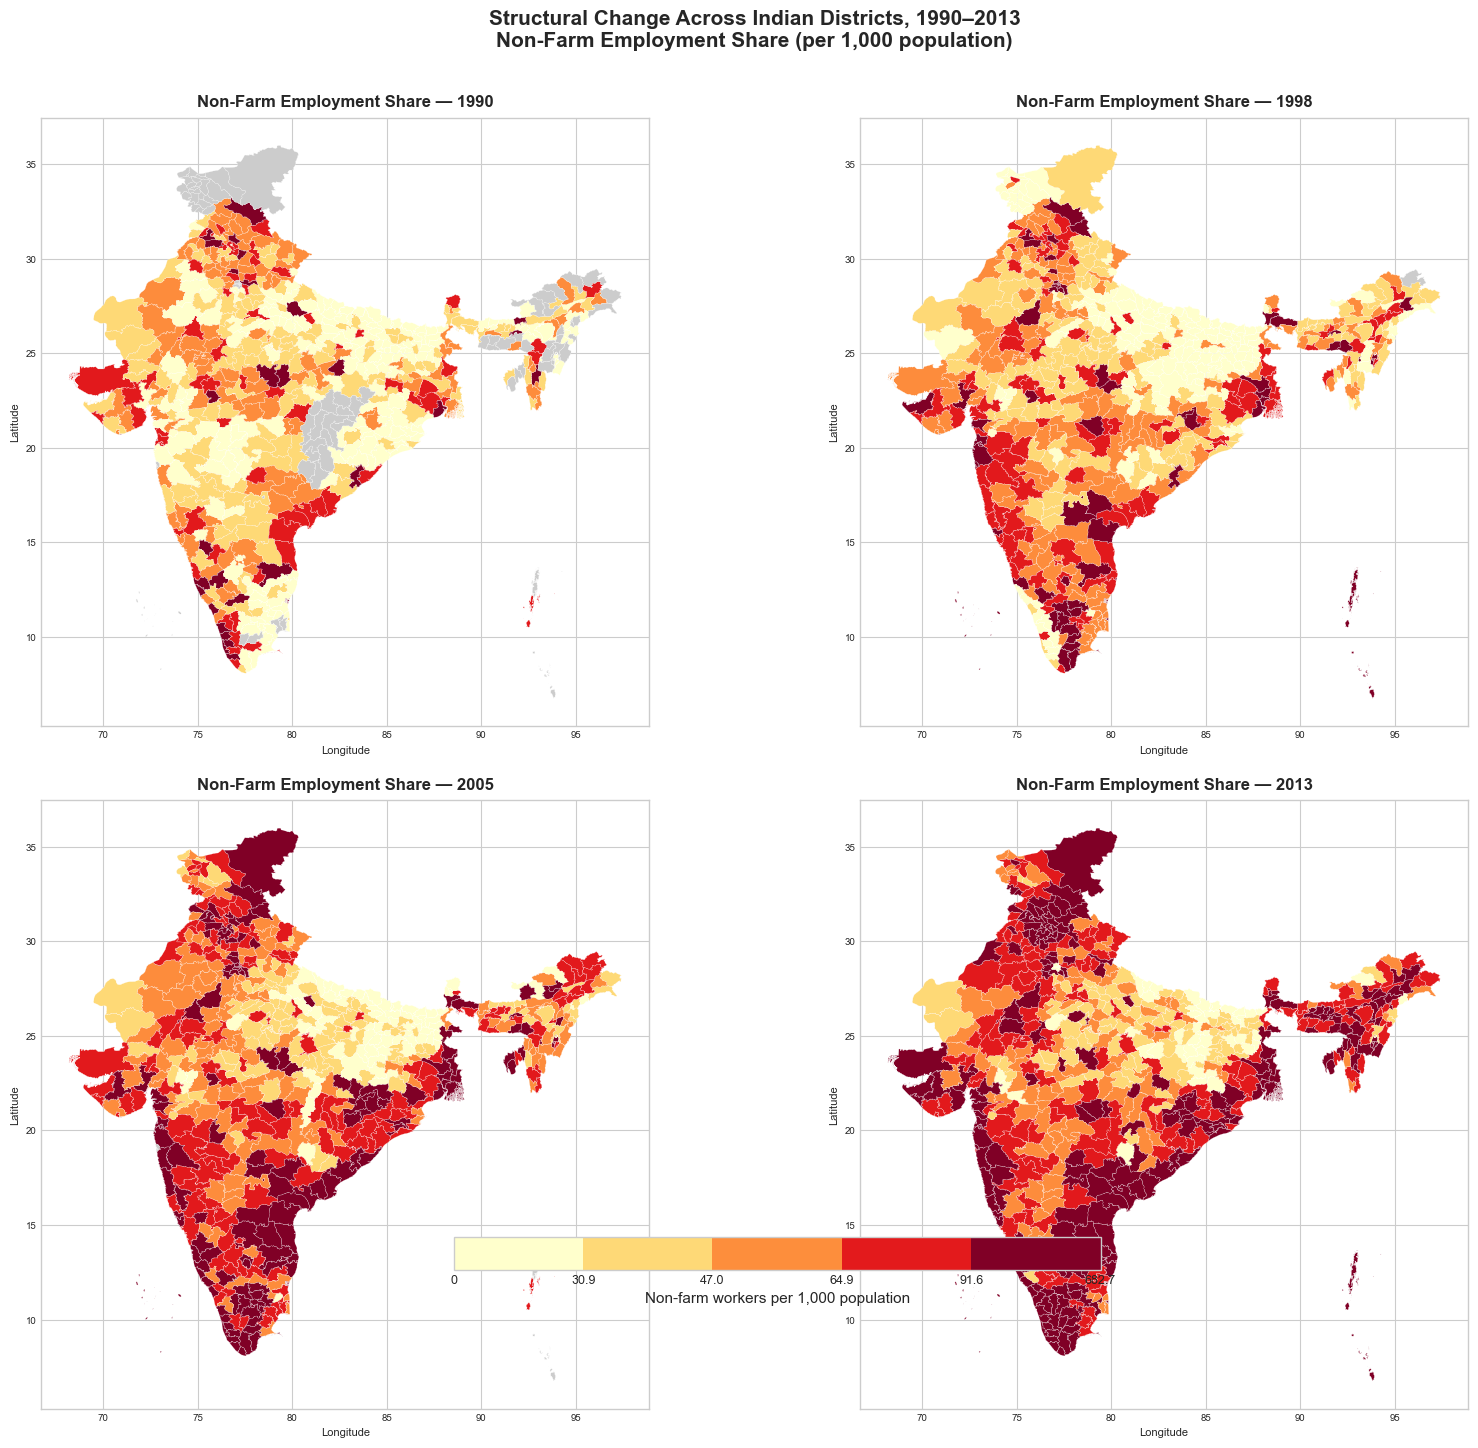

Saved: ../figures/nonfarm_share_4panel.png


In [3]:
# ─────────────────────────────────────────────────────────────
# Stage 2 — Four-panel non-farm employment share map
# ─────────────────────────────────────────────────────────────

rounds = [
    ('nonfarm_share_90', '1990'),
    ('nonfarm_share_98', '1998'),
    ('nonfarm_share_05', '2005'),
    ('nonfarm_share_13', '2013'),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for i, (col, year) in enumerate(rounds):
    ax = axes[i]

    panel.plot(
        column              = col,
        ax                  = ax,
        scheme              = 'user_defined',
        classification_kwds = {'bins': breaks},
        cmap                = 'YlOrRd',
        legend              = False,
        missing_kwds        = {'color': '#cccccc', 'label': 'No data'},
        edgecolor           = 'white',
        linewidth           = 0.15
    )

    ax.set_title(f'Non-Farm Employment Share — {year}',
                 fontsize=12, fontweight='bold', pad=8)
    ax.set_xlabel('Longitude', fontsize=8)
    ax.set_ylabel('Latitude', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.set_aspect('equal')

# ── Shared legend ─────────────────────────────────────────────
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable

cmap  = plt.cm.YlOrRd
norm  = BoundaryNorm([0] + list(breaks), cmap.N)
sm    = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=axes, orientation='horizontal',
                    fraction=0.03, pad=0.04, shrink=0.6)
cbar.set_label('Non-farm workers per 1,000 population', fontsize=11)
cbar.set_ticks([0] + list(breaks))
cbar.set_ticklabels(['0', '30.9', '47.0', '64.9', '91.6', '682.7'], 
                    fontsize=9)

fig.suptitle(
    'Structural Change Across Indian Districts, 1990–2013\n'
    'Non-Farm Employment Share (per 1,000 population)',
    fontsize=15, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.savefig(FIGURES / 'nonfarm_share_4panel.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES / 'nonfarm_share_4panel.png'}")

### Stage 2 — Output: Non-Farm Employment Share, 1990–2013

The four-panel map documents the spatial evolution of structural
transformation across Indian districts over two decades.

**Key spatial patterns:**

- **1990:** Structural transformation is geographically concentrated in
  isolated clusters — coastal Tamil Nadu, Gujarat, NCR/Delhi. Most of
  the interior remains in the lowest quintile. EC1990 coverage gaps
  (grey) are concentrated in central and eastern India.

- **1998:** Near-complete coverage. The south consolidates as the leading
  region. Tamil Nadu, Kerala, and coastal Andhra Pradesh are uniformly
  dark. The north-south gradient begins to emerge clearly.

- **2005:** The gradient sharpens. Gujarat's industrial belt is now
  visibly distinct from the neighbouring agrarian interior. The Northeast
  shows emerging heterogeneity. MP, Chhattisgarh, Bihar remain
  predominantly pale.

- **2013:** Broad darkening reflects economy-wide transformation, but
  the spatial hierarchy established in 1990 is preserved. Early
  industrialisers remain leaders. The interior has closed some gap
  but has not caught up.

**Interpretation:** Structural transformation in India over 1990–2013
was spatially concentrated and path-dependent. Coastal and urban districts
that industrialised early maintained their lead. This pattern is consistent
with trade-linked industrialisation being geographically tied to port
access and pre-existing industrial infrastructure — the hypothesis
examined further in Notebook 3.

Figure saved to `figures/nonfarm_share_4panel.png`.

## Stage 3 — Manufacturing Share Maps (1990–2013)

Non-farm employment includes both manufacturing and services. Districts
can transition out of agriculture in two structurally different ways:
into manufacturing (the classic industrialisation path) or directly into
low-productivity services (the "premature deindustrialisation" concern
raised in the development literature for countries like India).

Manufacturing share — defined as manufacturing employment as a share of
total non-farm employment — distinguishes these two pathways spatially.
High manufacturing share districts are industrialising; low manufacturing
share districts are transitioning into services without an industrial
phase.

We use the same common-scale approach as Stage 2.

Common quantile breaks for manufacturing share:
['0.161', '0.212', '0.261', '0.327', '0.809']


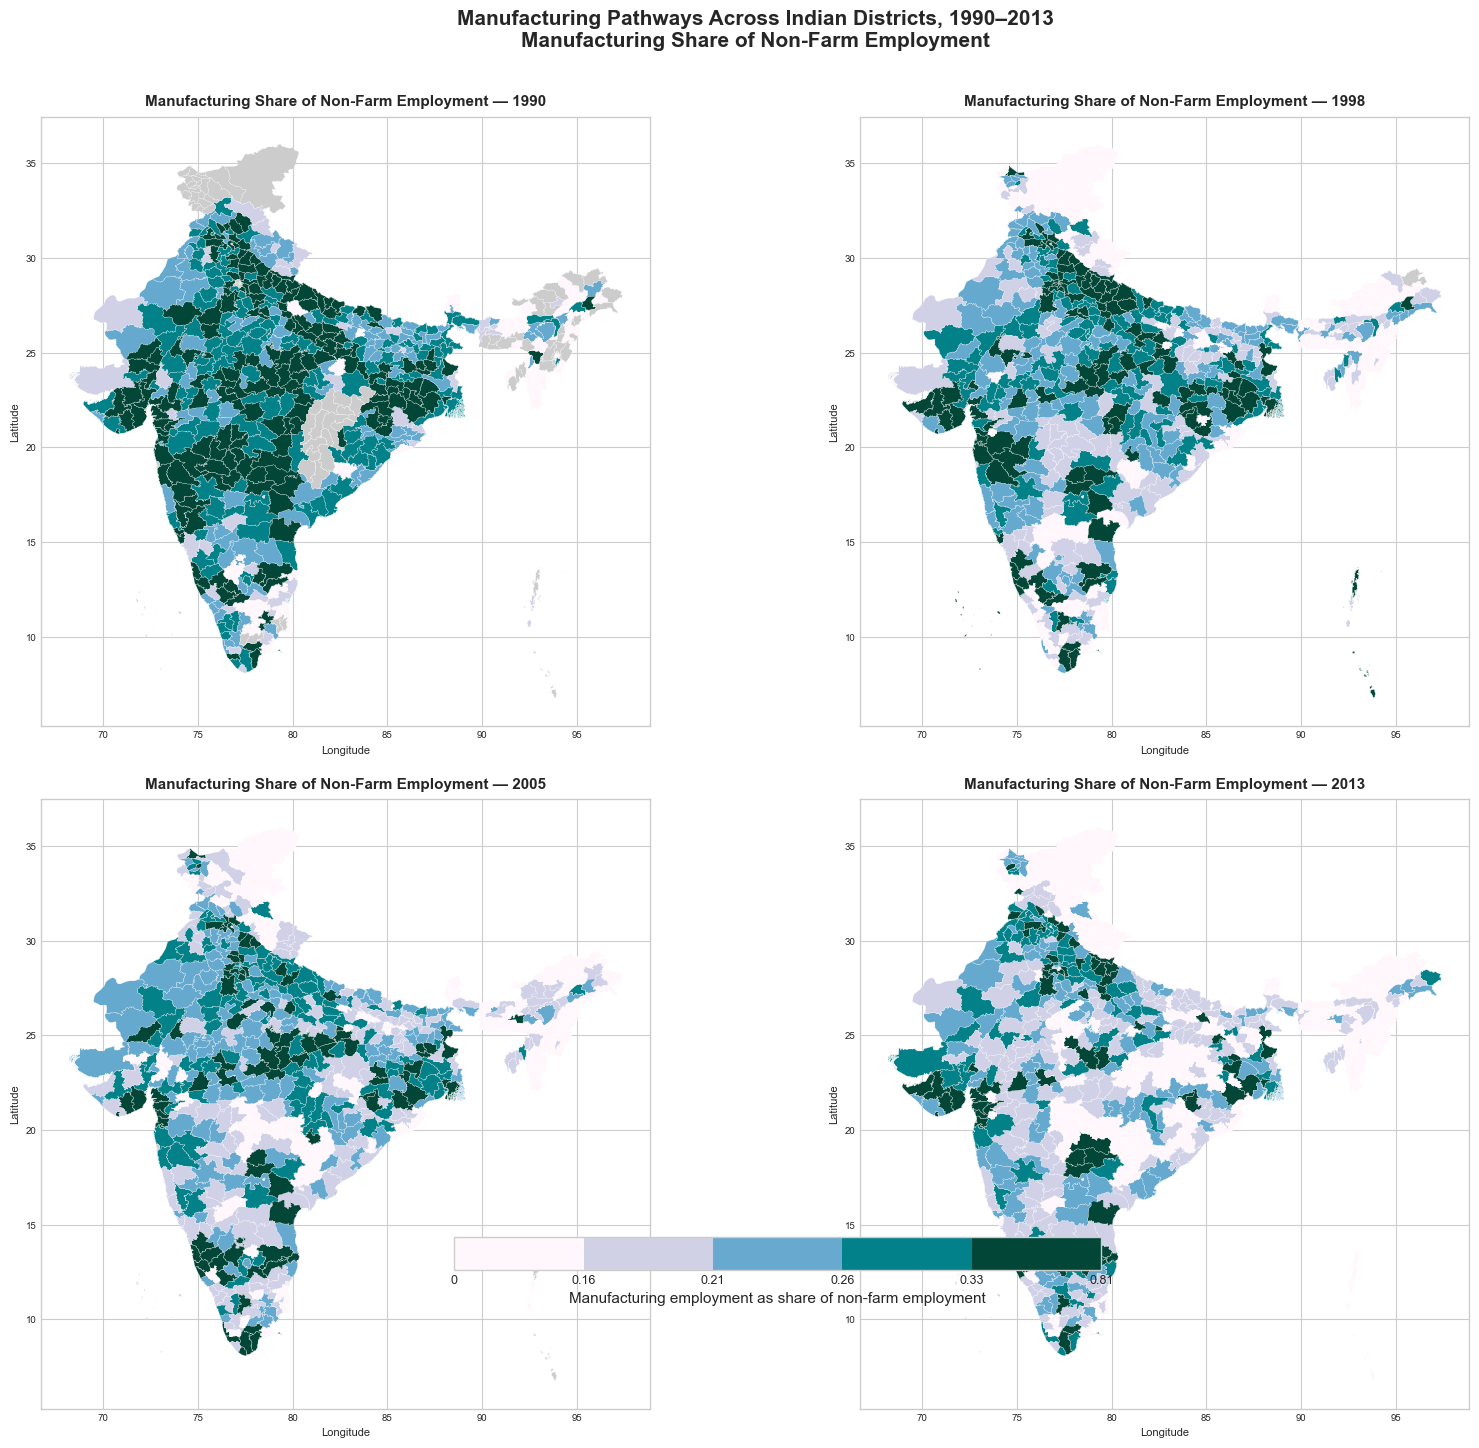

Saved: ../figures/manuf_share_4panel.png


In [4]:
# ─────────────────────────────────────────────────────────────
# Stage 3 — Four-panel manufacturing share map
# ─────────────────────────────────────────────────────────────

# Common scale across all four rounds
manuf_cols = ['manuf_share_90', 'manuf_share_98',
              'manuf_share_05', 'manuf_share_13']

pooled_manuf = pd.concat([panel[c].dropna() for c in manuf_cols])
breaks_manuf = mapclassify.Quantiles(pooled_manuf, k=5).bins

print("Common quantile breaks for manufacturing share:")
print([f"{b:.3f}" for b in breaks_manuf])

rounds_manuf = [
    ('manuf_share_90', '1990'),
    ('manuf_share_98', '1998'),
    ('manuf_share_05', '2005'),
    ('manuf_share_13', '2013'),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for i, (col, year) in enumerate(rounds_manuf):
    ax = axes[i]

    panel.plot(
        column              = col,
        ax                  = ax,
        scheme              = 'user_defined',
        classification_kwds = {'bins': breaks_manuf},
        cmap                = 'PuBuGn',
        legend              = False,
        missing_kwds        = {'color': '#cccccc', 'label': 'No data'},
        edgecolor           = 'white',
        linewidth           = 0.15
    )

    ax.set_title(f'Manufacturing Share of Non-Farm Employment — {year}',
                 fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('Longitude', fontsize=8)
    ax.set_ylabel('Latitude', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.set_aspect('equal')

# ── Shared legend ─────────────────────────────────────────────
cmap_m = plt.cm.PuBuGn
norm_m = BoundaryNorm([0] + list(breaks_manuf), cmap_m.N)
sm_m   = ScalarMappable(cmap=cmap_m, norm=norm_m)
sm_m.set_array([])

cbar_m = fig.colorbar(sm_m, ax=axes, orientation='horizontal',
                      fraction=0.03, pad=0.04, shrink=0.6)
cbar_m.set_label('Manufacturing employment as share of non-farm employment',
                 fontsize=11)
tick_labels = ['0'] + [f"{b:.2f}" for b in breaks_manuf]
cbar_m.set_ticks([0] + list(breaks_manuf))
cbar_m.set_ticklabels(tick_labels, fontsize=9)

fig.suptitle(
    'Manufacturing Pathways Across Indian Districts, 1990–2013\n'
    'Manufacturing Share of Non-Farm Employment',
    fontsize=15, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.savefig(FIGURES / 'manuf_share_4panel.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES / 'manuf_share_4panel.png'}")

### Stage 3 — Output: Manufacturing Share of Non-Farm Employment, 1990–2013

**Key spatial patterns:**

- **1990:** High manufacturing share is widespread — reflecting a narrow
  non-farm base dominated by traditional manufacturing (handlooms, small
  workshops, agro-processing) rather than industrial sophistication.

- **1998:** Fragmentation begins. Gujarat and the NCR corridor maintain
  high manufacturing intensity. Coastal southern districts show lower
  manufacturing shares despite high total non-farm employment — indicating
  services-led growth in those districts.

- **2005:** Broad lightening across the map. India's services boom
  (IT, telecom, finance) absorbs non-farm workers in southern urban
  districts without a commensurate rise in manufacturing. Manufacturing
  growth becomes more geographically concentrated.

- **2013:** Distinct manufacturing clusters emerge — Gujarat's industrial
  belt, parts of Haryana and western UP, select Tamil Nadu districts —
  surrounded by districts where services dominate the non-farm base.

**Interpretation:** Rising aggregate non-farm employment share (Stage 2)
masks two structurally different pathways: manufacturing-led
industrialisation (Gujarat, northern plains industrial belt) and
services-led transformation (coastal south, metropolitan peripheries).
This distinction has direct policy implications for industrial strategy
and fiscal planning — a core concern of this portfolio's research agenda.

Figure saved to `figures/manuf_share_4panel.png`.

## Stage 4 — Change Maps: Where Did Structural Transformation Accelerate?

The level maps in Stages 2 and 3 show the stock of structural change at
each point in time. The change maps show the flow — which districts
transformed fastest and when.

We produce two change maps:
- **Full period (1990→2013):** Absolute change in non-farm employment
  share over the entire post-liberalisation window. Districts with
  missing 1990 data are excluded.
- **Recent period (2005→2013):** Change over the most recent EC interval,
  capturing the post-2005 acceleration phase. Near-complete coverage.

A diverging colour scheme is used — blue for districts where non-farm
share increased (the expected direction), and the rare red for districts
where it declined.

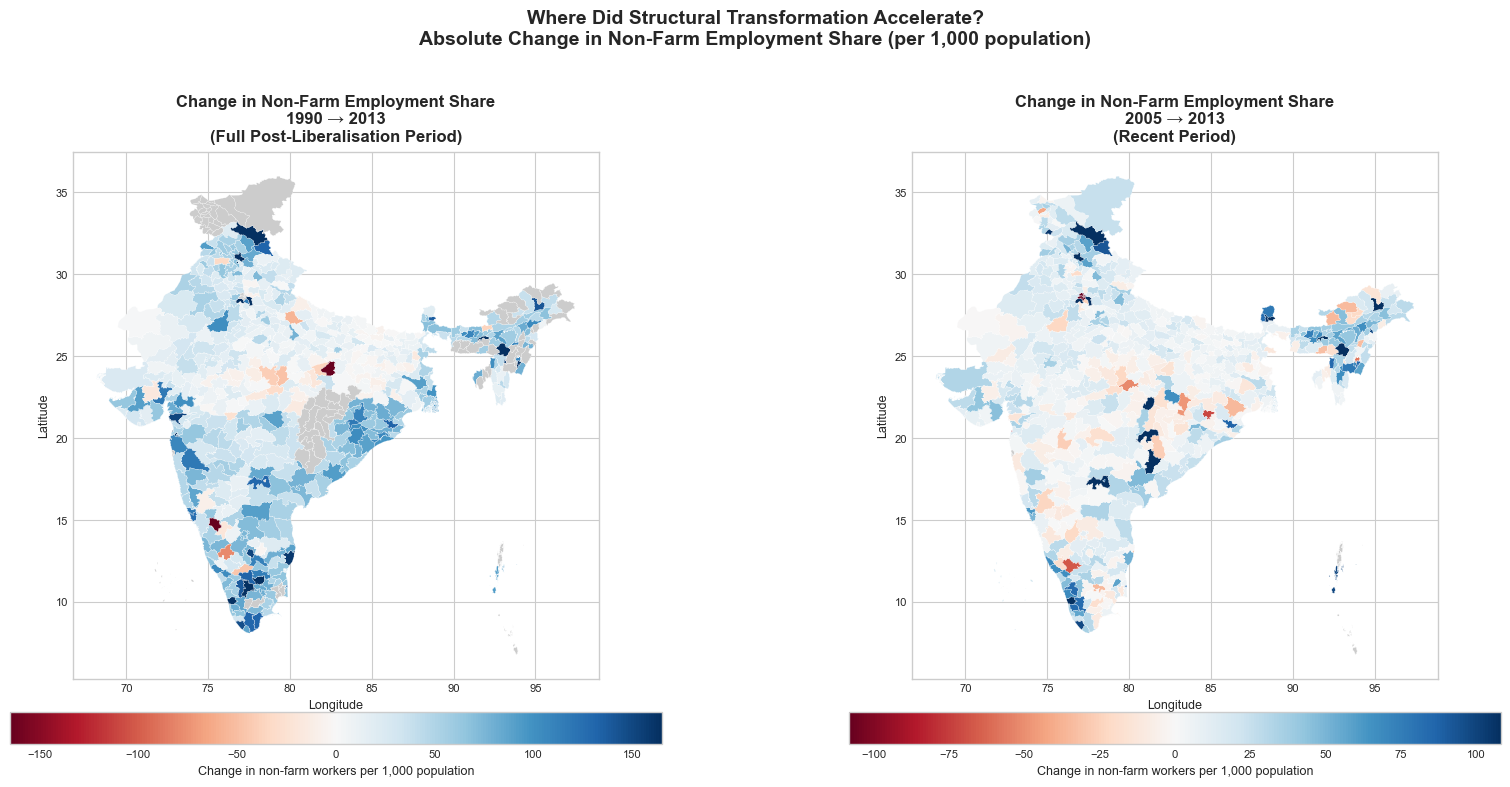

Saved: ../figures/change_nonfarm_2panel.png


In [6]:
# ─────────────────────────────────────────────────────────────
# Stage 4 — Change maps: full period and recent period
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

change_vars = [
    ('delta_nonfarm_90_13', '1990 → 2013\n(Full Post-Liberalisation Period)'),
    ('delta_nonfarm_05_13', '2005 → 2013\n(Recent Period)'),
]

for i, (col, title) in enumerate(change_vars):
    ax = axes[i]

    # Symmetric diverging scale around zero (2nd–98th percentile)
    vals    = panel[col].dropna()
    abs_max = max(abs(vals.quantile(0.02)), abs(vals.quantile(0.98)))

    panel.plot(
        column       = col,
        ax           = ax,
        cmap         = 'RdBu',
        vmin         = -abs_max,
        vmax         =  abs_max,
        legend       = False,
        missing_kwds = {'color': '#cccccc', 'label': 'No data'},
        edgecolor    = 'white',
        linewidth    = 0.15
    )

    # Manual colorbar per subplot
    sm = ScalarMappable(
        cmap = plt.cm.RdBu,
        norm = plt.Normalize(vmin=-abs_max, vmax=abs_max)
    )
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation='horizontal',
                        shrink=0.7, pad=0.05)
    cbar.set_label('Change in non-farm workers per 1,000 population',
                   fontsize=9)
    cbar.ax.tick_params(labelsize=8)

    ax.set_title(f'Change in Non-Farm Employment Share\n{title}',
                 fontsize=12, fontweight='bold', pad=8)
    ax.set_xlabel('Longitude', fontsize=9)
    ax.set_ylabel('Latitude', fontsize=9)
    ax.tick_params(labelsize=8)
    ax.set_aspect('equal')

fig.suptitle(
    'Where Did Structural Transformation Accelerate?\n'
    'Absolute Change in Non-Farm Employment Share (per 1,000 population)',
    fontsize=14, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig(FIGURES / 'change_nonfarm_2panel.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES / 'change_nonfarm_2panel.png'}")

In [7]:
# ─────────────────────────────────────────────────────────────
# Stage 4 — Diagnose districts with negative change
# ─────────────────────────────────────────────────────────────

# Full period decliners
decliners_90_13 = panel[panel['delta_nonfarm_90_13'] < 0][
    ['DISTRICT', 'ST_NM', 
     'nonfarm_share_90', 'nonfarm_share_13', 
     'delta_nonfarm_90_13']
].sort_values('delta_nonfarm_90_13')

print(f"Districts with negative change 1990→2013: {len(decliners_90_13)}")
print(decliners_90_13.to_string())

print(f"\n{'─'*60}")

# Recent period decliners
decliners_05_13 = panel[panel['delta_nonfarm_05_13'] < 0][
    ['DISTRICT', 'ST_NM',
     'nonfarm_share_05', 'nonfarm_share_13',
     'delta_nonfarm_05_13']
].sort_values('delta_nonfarm_05_13')

print(f"\nDistricts with negative change 2005→2013: {len(decliners_05_13)}")
print(decliners_05_13.to_string())

Districts with negative change 1990→2013: 57
            DISTRICT           ST_NM  nonfarm_share_90  nonfarm_share_13  delta_nonfarm_90_13
223           Haveri       Karnataka          365.0239           63.7341            -301.2898
527        Singrauli  Madhya Pradesh          178.7140           14.4467            -164.2673
221           Hassan       Karnataka          158.7369           79.8150             -78.9219
219           Hardoi   Uttar Pradesh           95.3838           39.7872             -55.5966
131            Damoh  Madhya Pradesh          133.1664           85.4023             -47.7641
103     Chamrajnagar       Karnataka          119.3221           74.1376             -45.1844
487            Sagar  Madhya Pradesh          136.2788           95.5169             -40.7619
352             Mahe      Puducherry          206.8734          167.2805             -39.5930
634            Yanam      Puducherry          194.1174          154.9635             -39.1539
582         Uda

In [8]:
# ─────────────────────────────────────────────────────────────
# Stage 4 — Flag outlier districts for transparent reporting
# ─────────────────────────────────────────────────────────────

# Threshold: changes more extreme than 3 standard deviations
# from the mean are flagged as likely data artefacts

for col, label in [('delta_nonfarm_90_13', '1990→2013'),
                   ('delta_nonfarm_05_13', '2005→2013')]:
    vals   = panel[col].dropna()
    mean   = vals.mean()
    std    = vals.std()
    lower  = mean - 3 * std
    upper  = mean + 3 * std

    outliers = panel[
        (panel[col] < lower) | (panel[col] > upper)
    ][['DISTRICT', 'ST_NM', col]]

    print(f"\n{label} — mean={mean:.1f}, std={std:.1f}")
    print(f"  3σ bounds: [{lower:.1f}, {upper:.1f}]")
    print(f"  Flagged outliers ({len(outliers)}):")
    print(outliers.to_string())


1990→2013 — mean=40.1, std=49.1
  3σ bounds: [-107.2, 187.4]
  Flagged outliers (9):
                 DISTRICT                   ST_NM  delta_nonfarm_90_13
106            Chandigarh              Chandigarh             212.9858
126  Dadra & Nagar Haveli  Dadara & Nagar Havelli             205.6684
194   Gautam Buddha Nagar           Uttar Pradesh             280.0978
211               Gurgaon                 Haryana             370.1454
223                Haveri               Karnataka            -301.2898
269   Kamrup Metropolitan                   Assam             209.3631
413            Dima Hasao                   Assam             245.1722
527             Singrauli          Madhya Pradesh            -164.2673
535                 Solan        Himachal Pradesh             191.2274

2005→2013 — mean=8.0, std=72.3
  3σ bounds: [-208.9, 224.9]
  Flagged outliers (10):
       DISTRICT         ST_NM  delta_nonfarm_05_13
98      Central  NCT of Delhi            -520.4369
164        East 

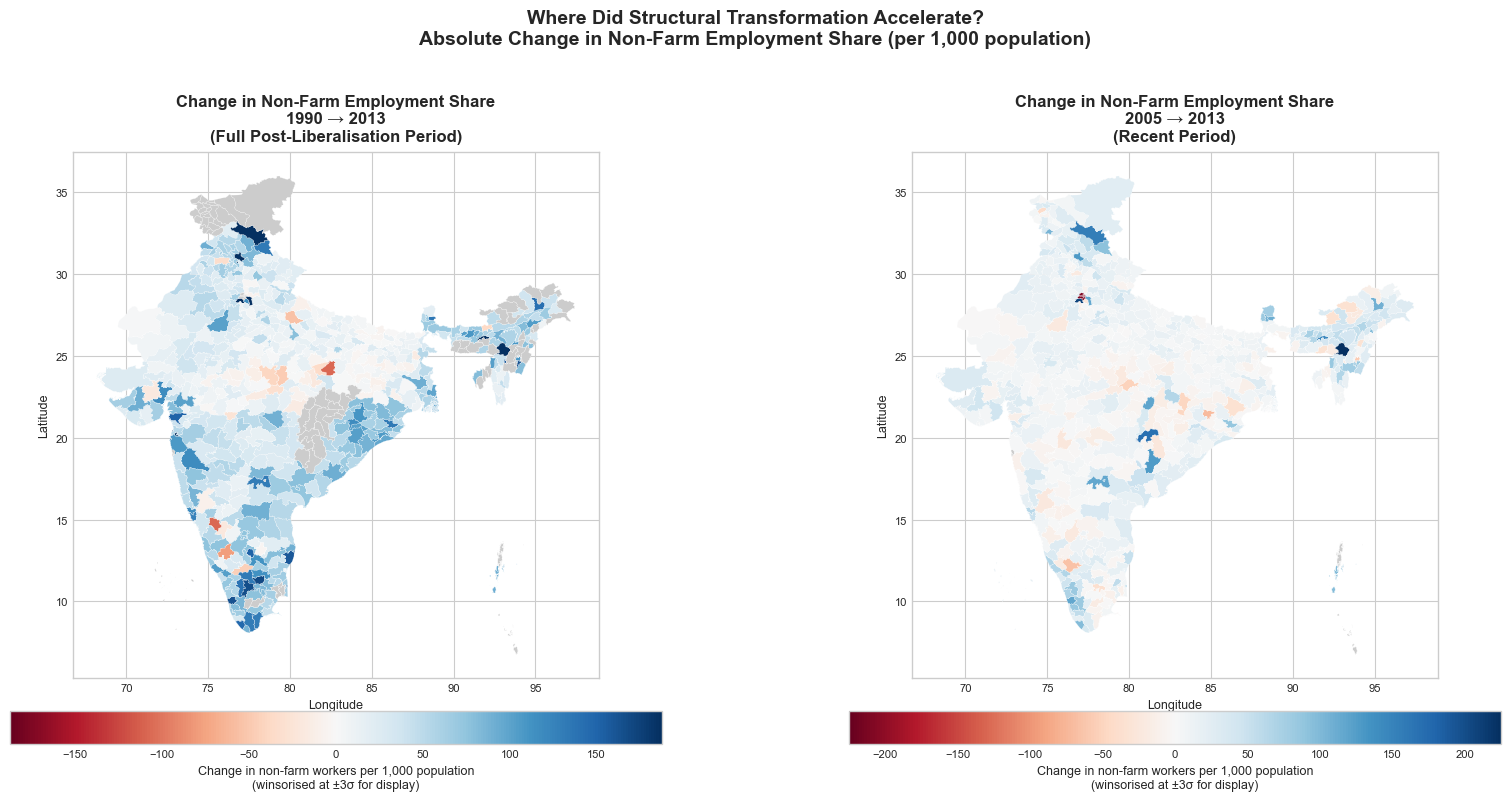

Saved: ../figures/change_nonfarm_2panel.png


In [9]:
# ─────────────────────────────────────────────────────────────
# Stage 4 — Winsorised change maps (outliers clipped for display)
# ─────────────────────────────────────────────────────────────

# Create winsorised display columns (does NOT modify original data)
for col in ['delta_nonfarm_90_13', 'delta_nonfarm_05_13']:
    vals  = panel[col].dropna()
    lower = vals.mean() - 3 * vals.std()
    upper = vals.mean() + 3 * vals.std()
    panel[f'{col}_wins'] = panel[col].clip(lower=lower, upper=upper)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

change_vars = [
    ('delta_nonfarm_90_13_wins', '1990 → 2013\n(Full Post-Liberalisation Period)'),
    ('delta_nonfarm_05_13_wins', '2005 → 2013\n(Recent Period)'),
]

for i, (col, title) in enumerate(change_vars):
    ax = axes[i]

    vals    = panel[col].dropna()
    abs_max = max(abs(vals.min()), abs(vals.max()))

    panel.plot(
        column       = col,
        ax           = ax,
        cmap         = 'RdBu',
        vmin         = -abs_max,
        vmax         =  abs_max,
        legend       = False,
        missing_kwds = {'color': '#cccccc', 'label': 'No data'},
        edgecolor    = 'white',
        linewidth    = 0.15
    )

    sm = ScalarMappable(
        cmap = plt.cm.RdBu,
        norm = plt.Normalize(vmin=-abs_max, vmax=abs_max)
    )
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation='horizontal',
                        shrink=0.7, pad=0.05)
    cbar.set_label('Change in non-farm workers per 1,000 population\n'
                   '(winsorised at ±3σ for display)',
                   fontsize=9)
    cbar.ax.tick_params(labelsize=8)

    ax.set_title(f'Change in Non-Farm Employment Share\n{title}',
                 fontsize=12, fontweight='bold', pad=8)
    ax.set_xlabel('Longitude', fontsize=9)
    ax.set_ylabel('Latitude', fontsize=9)
    ax.tick_params(labelsize=8)
    ax.set_aspect('equal')

fig.suptitle(
    'Where Did Structural Transformation Accelerate?\n'
    'Absolute Change in Non-Farm Employment Share (per 1,000 population)',
    fontsize=14, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig(FIGURES / 'change_nonfarm_2panel.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES / 'change_nonfarm_2panel.png'}")

### Stage 4 — Output: Change Maps

**Step 1 — First pass revealed an anomaly**

The initial change maps showed a small number of districts with extreme
negative values — implying non-farm employment *declined* sharply over
the period. Before interpreting this as a real economic phenomenon, we
investigated whether these were genuine or artefacts of the data pipeline.

**Step 2 — Diagnosing the negative-change districts**

Inspecting the 57 districts with negative 1990→2013 change and 152 with
negative 2005→2013 change revealed two distinct categories:

*Category A — Data artefacts from EC1990 boundary harmonisation:*
Districts like Haveri (Karnataka, -301) and Singrauli (MP, -164) showed
implausibly high 1990 baselines — Haveri at 365 non-farm workers per
1,000 population, which is unrealistically high for a predominantly rural
district. This reflects a known limitation of the 1990 Economic Census:
MOSPI was unable to provide a location directory for that round, resulting
in low and uneven shrid match rates. A small number of large establishments
matched to certain shrids in 1990 inflated those district totals; when
those establishments were not re-matched in 2013 due to boundary changes,
the computed change appeared negative. These are not real economic declines.

*Category B — Administrative boundary reorganisation:*
All nine NCT of Delhi districts showed extreme negative 2005→2013 changes
(around -540 per 1,000). Delhi's administrative districts were reorganised
between the 2001 and 2011 Census rounds — employment that was attributed
to a small number of large units in 2005 was redistributed across more,
smaller units by 2013, producing apparent but spurious declines. Again,
not a real economic phenomenon.

*Category C — Genuine mild declines:*
A larger set of districts (Bihar, Jharkhand, interior MP) showed small
negative changes of 0–10 per 1,000. These are plausibly real — districts
where population growth outpaced non-farm employment growth, so the share
declined slightly. These are retained as-is in the data and maps.

**Step 3 — Identifying outliers systematically**

To distinguish extreme artefacts from genuine variation in a principled
way, we used a standard statistical threshold: values more than three
standard deviations (3σ) from the mean of the change distribution were
flagged as outliers. For the 1990→2013 distribution (mean = 40.1,
std = 49.1), this gives bounds of [-107.2, 187.4]. Nine districts fell
outside these bounds. For 2005→2013 (mean = 8.0, std = 72.3), ten
districts were flagged — all nine Delhi districts plus Dima Hasao (Assam,
a genuine rapid transformer whose extreme value reflects real change).

**Step 4 — Winsorisation for display**

Winsorisation is a standard technique for handling extreme values in
visualisation: observations beyond the 3σ threshold are *clipped* to the
threshold value rather than excluded entirely. This preserves the spatial
pattern across the remaining 630+ districts without allowing a handful of
outliers to compress the colour scale into uninformativeness. Crucially,
the underlying data in the GeoPackage is unchanged — winsorisation is
applied only to the display variable, and the notebook documents this
explicitly.

**Key findings from the winsorised maps:**

- Structural transformation was **front-loaded** — the 1990→2013 map
  shows far more spatial variation than 2005→2013, indicating the bulk
  of dramatic change occurred in the earlier sub-period.
- The **NCR satellite belt** (Gurgaon, Gautam Buddha Nagar) shows the
  largest sustained positive change over the full period — consistent
  with industrial corridor development and urbanisation-driven structural
  change.
- **Interior laggards** (Bihar, Jharkhand, MP) show near-zero or mildly
  negative recent change — population growth outpacing non-farm
  employment growth in 2005→2013.
- The **2005→2013 deceleration** across most districts is consistent
  with the slowdown in India's manufacturing growth post-Global
  Financial Crisis documented in the broader literature.

Figure saved to `figures/change_nonfarm_2panel.png`.

## Notebook 2 — Summary

This notebook produced three sets of maps documenting structural change
across Indian districts from 1990 to 2013, and introduced an important
methodological lesson about working with historical administrative data.

**Maps produced:**

1. **Non-farm employment share (4-panel):** Documents the geography of
   structural transformation on a common quantile scale across all four
   rounds. Coastal and urban districts lead persistently; the agrarian
   interior lags throughout.

2. **Manufacturing share (4-panel):** Reveals two structurally different
   transformation pathways — manufacturing-led industrialisation (Gujarat,
   northern plains industrial belt) vs. services-led transformation
   (coastal south, metropolitan peripheries). Manufacturing share declines
   over time as a share of the growing non-farm base.

3. **Change maps (2-panel):** Constructed in two passes. The first pass
   revealed anomalous negative-change districts that were diagnosed as
   a mix of EC1990 boundary harmonisation artefacts, Delhi administrative
   reorganisation, and genuine mild declines. Extreme outliers (>3σ) were
   identified and winsorised for display — a standard technique that
   preserves the colour scale's informativeness without discarding data.
   The second pass produced interpretable maps showing that transformation
   was front-loaded in the pre-2005 period and decelerated thereafter.

**Methodological note:**
Working with multi-round administrative census data requires continuous
vigilance about data quality. The negative-change diagnosis in Stage 4
illustrates how an apparently simple output — a change map — can surface
data pipeline issues that must be investigated before interpretation.
Transparent documentation of these issues, rather than silent exclusion,
is essential for reproducible research.

**Figures produced:**
- `figures/nonfarm_share_4panel.png`
- `figures/manuf_share_4panel.png`
- `figures/change_nonfarm_2panel.png`

**Ready for Notebook 3:** Trade Exposure Proxies and Spatial Analysis.